In [44]:
import pandas as pd

df = pd.read_csv("wildfire_model_data.csv")

df.head()

,fire_id,fire_size,ignition_date,containment_date,duration_days,latitude,longitude,ignition_year,ignition_month,hot_days_6mo,...,grass_fraction,agriculture_fraction,nonburnable_fraction,dominant_veg,avg_vpd_6mo,avg_wind_6mo,extreme_fire_days,avg_precip_6mo,rainy_days_6mo,avg_humidity_6mo
0,10TH_2024_00139,131.961304,2023-06-25 00:00:00,2024-06-25 00:00:00,366,34.971166,-118.109886,2023,6,12.0,...,0.000000,0.000000,0.000000,shrub_fraction,1.305639,4.746389,0.0,0.888333,36.0,70.537315
1,10_2003_07027,212.883774,2002-09-03 00:00:00,2003-09-10 00:00:00,372,40.132079,-124.084808,2002,9,NaN,...,0.569161,0.000000,0.003401,grass_fraction,0.714181,4.684583,0.0,3.983750,50.0,91.340555
2,118_FWY_2015_03742,4.027377,2014-06-04 00:00:00,2015-06-04 00:00:00,365,34.275892,-118.625533,2014,6,NaN,...,0.000000,0.000000,0.000000,shrub_fraction,1.149972,3.034537,0.0,0.889167,21.0,71.191667
3,128_2002_07316,187.959915,2001-09-04 00:00:00,2002-09-05 00:00:00,366,38.507163,-122.091515,2001,9,29.0,...,0.002083,0.000000,0.040278,shrub_fraction,1.603065,3.868611,3.0,0.397593,16.0,80.550648
4,128_2006_06210,57.198334,2005-07-07 00:00:00,2006-07-07 00:00:00,365,38.438790,-122.169162,2005,7,7.0,...,0.000000,0.117063,0.835317,shrub_fraction,0.857130,3.379537,0.0,3.104537,68.0,85.048611


In [45]:
df.shape

(7662, 44)

In [46]:
df.isna().sum()

fire_id                     0
fire_size                   0
ignition_date               0
containment_date            0
duration_days               0
latitude                    0
longitude                   0
ignition_year               0
ignition_month              0
hot_days_6mo             2644
avg_fm100_6mo              19
avg_fm1000_6mo             19
days_fm100_below_10         1
avg_max_temp_6mo           19
avg_min_temp_6mo           19
hottest_day_6mo            19
coldest_day_6mo            19
avg_daily_temp_range       19
mean_elevation           1148
elevation_variability    1148
mean_slope               1149
open_water                  0
barren                      0
forest_decid                0
forest_ever                 0
forest_mixed                0
shrub                       0
grassland                   0
pasture                     0
crops                       0
wetland                     0
wetland_herb                0
forest_fraction             0
shrub_frac

# Drops the NA values

In [47]:
df = df.dropna()

# We calculate log fire size 

In [48]:
import numpy as np

df["log_fire_size"] = np.log(df["fire_size"] + 1)

In [65]:
features = [
    "mean_elevation",
    "nonburnable_fraction",
    "extreme_fire_days",
    "avg_fm100_6mo",
    "hot_days_6mo",
    "avg_max_temp_6mo",
    "avg_humidity_6mo",
    "avg_precip_6mo",
]

X = df[features]
y = df["log_fire_size"]

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [69]:
y_pred = model.predict(X_test_scaled)

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 2.0318327769037245
R2: 0.06321811528696364


In [56]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
0,mean_elevation,0.482812
6,avg_humidity_6mo,0.131881
4,hot_days_6mo,0.115160
7,avg_precip_6mo,0.062438
5,avg_max_temp_6mo,0.030904
1,nonburnable_fraction,0.025885
3,avg_fm100_6mo,0.007390
2,extreme_fire_days,-0.148452


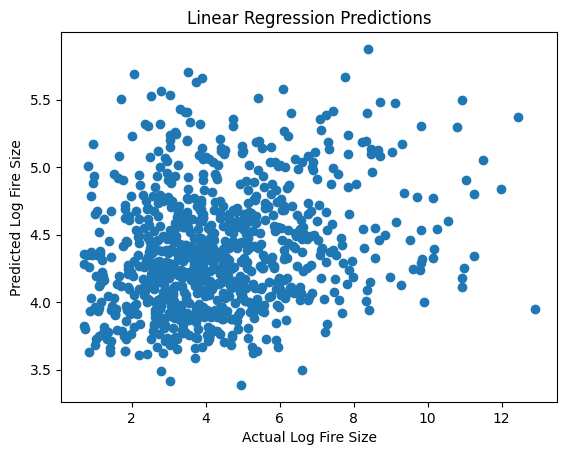

In [43]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Log Fire Size")
plt.ylabel("Predicted Log Fire Size")
plt.title("Linear Regression Predictions")
plt.show()